<h1>Nutri-Score Prediction Model<h1>

# <h2>Introduction</h2>

The goal of this project is to predict the Nutri-Score grade for a given food item. To do this, we will train machine learning models to take various ingredients into account to predict the score. The models we will train will use this information to place the food into a Nutri-Score category from worst to best.

The dataset we will be using is the **foods_health_scores_allergens**. This dataset is part of a larger dataset called **"Global Food & Nutrition Database 2026"** created by **Muhammad Ahsan** under the **CC BY-SA 4.0** license.

https://www.kaggle.com/datasets/ahsanneural/global-food-and-nutrition-database-2026?select=foods_health_scores_allergens.csv

# <h2>Task 1: Loading the Dataset</h2>

To start, we will be loading our dataset. Below is a step by step process in downloading the dataset and importing the file we will be using.

# <h4>Step 1: Installing the dataset.</h4>

In [40]:
!pip install kaggle

In [41]:
# this code will install the dataset into the files folder

!kaggle datasets download -d ahsanneural/global-food-and-nutrition-database-2026

Dataset URL: https://www.kaggle.com/datasets/ahsanneural/global-food-and-nutrition-database-2026
License(s): CC-BY-SA-4.0
global-food-and-nutrition-database-2026.zip: Skipping, found more recently modified local copy (use --force to force download)


# <h4>Step 2: Importing our datafile.</h4>

 Once the file is installed, open it and you will see it contains multiple csv files. We will only need one. The one we'll need is called **food_health_scores_allergens.csv**. To import it, simply drag it into the content section of the files folder.

Now that that we have our file, we can then run the following code to read our dataset.

In [42]:
import pandas as pd

#reading our dataset
df=pd.read_csv('/content/foods_health_scores_allergens.csv')

In [43]:
#displaying our first five rows
df.head()

,product_name,brands,categories,ingredients,nutriscore_grade,nova_group,ecoscore_grade,allergens,energy_kcal,fat_100g,...,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,food_type
0,Sidi Ali,سيدي علي,"en:beverages-and-beverages-preparations, en:be...",OBD1 999 999 1112606 266963207 mb,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000000,0.000000,False,False,False,False,False,False,Branded/Packaged
1,Perly,Perly,"en:dairies, en:fermented-foods, en:fermented-m...","milk cream, cream, sugar, banana, bacteria",UNKNOWN,3.0,B,"en:banana, en:milk",97.0,3.0,...,8.0,NaN,NaN,False,True,False,False,False,False,Branded/Packaged
2,Sidi Ali,Sidi Ali,"en:beverages-and-beverages-preparations, en:be...","Sodium, Calcium, Magnésium, Potassium, Bicarbo...",A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
3,Eau minérale naturelle,sidi ali,"en:beverages-and-beverages-preparations, en:be...",100% mineral water,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
4,اكوافينا,AQUAFINA,"en:beverages-and-beverages-preparations, en:be...",ouverture et avant le : Voir bouteille. après ...,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000508,0.000203,False,False,False,False,False,False,Branded/Packaged


Now that we've confirmed that our dataset is loaded in, we will move onto our next task which is cleaning the data.

# <h2>Task 2: Cleaning the Data</h2>

As with any project with the goal of data analysis or machine learning, we must clean the dataset.

First, we must understand the data. To do this, we will use df.info(). The reason we use this is to identify missing values, verify data types, and understand the data type for each column.

In [44]:
#understanding the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_name        4785 non-null   object 
 1   brands              4751 non-null   object 
 2   categories          4913 non-null   object 
 3   ingredients         4797 non-null   object 
 4   nutriscore_grade    4983 non-null   object 
 5   nova_group          4522 non-null   float64
 6   ecoscore_grade      4984 non-null   object 
 7   allergens           3332 non-null   object 
 8   energy_kcal         4682 non-null   float64
 9   fat_100g            4695 non-null   float64
 10  saturated_fat_100g  4617 non-null   float64
 11  carbs_100g          4676 non-null   float64
 12  sugars_100g         4631 non-null   float64
 13  fiber_100g          3495 non-null   float64
 14  proteins_100g       4690 non-null   float64
 15  salt_100g           4653 non-null   float64
 16  sodium

<h3>Insights</h3>

By observing this information, we notice that...

* There are 24 total columns. We may not use all of them.
* Null values are present.
* We are given three data types total. We are given **bool** (True or False), **float64** (decimal numbers), and **object** (a string).

Let's dig deeper to understand this dataset more by using **df.describe()**. We use **df.describe()** to provide a statistical summary of the dataset. In addition, we also get the opportunity to identify outliers and detect missing or extreme values.

**Note:** This will only include columns with numerical values.

In [45]:
#summarizing the data
df.describe()

,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,4522.000000,4682.000000,4695.000000,4617.000000,4676.000000,4631.000000,3.495000e+03,4690.000000,4653.000000,4653.000000
mean,3.278859,301.225402,15.997065,5.489583,32.598284,12.368927,1.748567e+09,7.348264,1.477237,0.590895
std,1.033540,221.661070,21.974815,12.451133,133.906873,22.020440,1.033727e+11,11.135688,14.776243,5.910491
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,3.000000,99.000000,1.500000,0.300000,4.800000,1.095000,5.000000e-01,1.700000,0.030000,0.012000
50%,4.000000,295.000000,7.420000,1.500000,19.700000,4.300000,3.000000e+00,6.300000,0.312000,0.125000
75%,4.000000,456.000000,23.000000,6.800000,58.000000,16.000000,6.600000e+00,9.600000,1.000000,0.400000
max,4.000000,5280.000000,554.000000,595.000000,8989.000000,895.000000,6.111242e+12,597.000000,898.000000,359.200000


<h3>Insights</h3>

* This shows again there are null values present.
* There are some extremely high values seen in the max values. They are much higher values than the upper quartile.


With all of this information, we can begin cleaning our dataset.

# <h4>Dropping unnecessary columns</h4>

In [46]:
#removing columns that won't be used. These columns were chosen to be removed because most of them are strings; They won't be necessary for our model.

df.drop(columns=['product_name', 'brands', 'categories', 'ingredients', 'ecoscore_grade', 'allergens', 'food_type'], inplace=True)

df.head()

,nutriscore_grade,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish
0,A,NaN,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.000000,0.000000,False,False,False,False,False,False
1,UNKNOWN,3.0,97.0,3.0,NaN,9.4,NaN,NaN,8.0,NaN,NaN,False,True,False,False,False,False
2,A,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000,False,False,False,False,False,False
3,A,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000,False,False,False,False,False,False
4,A,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000508,0.000203,False,False,False,False,False,False


# <h4>Removing Null Values</h4>

In [47]:
#initial null count
df.isna().sum()

,0
nutriscore_grade,14
nova_group,475
energy_kcal,315
fat_100g,302
saturated_fat_100g,380
carbs_100g,321
sugars_100g,366
fiber_100g,1502
proteins_100g,307
salt_100g,344


In [48]:
#removing null values.
df = df.dropna()

In [49]:
#displaying there are null values left
df.isna().sum()

,0
nutriscore_grade,0
nova_group,0
energy_kcal,0
fat_100g,0
saturated_fat_100g,0
carbs_100g,0
sugars_100g,0
fiber_100g,0
proteins_100g,0
salt_100g,0


# <h4>Removing Duplicate Values</h4>

In [50]:
#displaying duplicate values.
dupdf = df[df.duplicated(keep=False)]

In [51]:
dupdf.duplicated().sum()

np.int64(185)

In [52]:
df = df.drop_duplicates()

In [53]:
# displaying if any duplicate values are left.
df.duplicated().sum()

np.int64(0)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3073 entries, 6 to 4996
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nutriscore_grade    3073 non-null   object 
 1   nova_group          3073 non-null   float64
 2   energy_kcal         3073 non-null   float64
 3   fat_100g            3073 non-null   float64
 4   saturated_fat_100g  3073 non-null   float64
 5   carbs_100g          3073 non-null   float64
 6   sugars_100g         3073 non-null   float64
 7   fiber_100g          3073 non-null   float64
 8   proteins_100g       3073 non-null   float64
 9   salt_100g           3073 non-null   float64
 10  sodium_100g         3073 non-null   float64
 11  contains_gluten     3073 non-null   bool   
 12  contains_dairy      3073 non-null   bool   
 13  contains_nuts       3073 non-null   bool   
 14  contains_soy        3073 non-null   bool   
 15  contains_eggs       3073 non-null   bool   
 16  contains_fi

# <h4>Fixing Structural Errors</h4>

Because the correlation matrix won't work for bool data types, we will change the data type to integers.

In [55]:
#changing boolean for all bool columns to integers

for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

The **nutriscore_grade** column is our main focus because it is what our model will try to predict. However, it is currently a string. To make our model include it, we will have to change its data type too.

In [56]:
# displaying the current nutriscore_grade values

df.value_counts(subset=['nutriscore_grade'])

,count
nutriscore_grade,
C,785
D,587
A,584
E,547
B,445
UNKNOWN,64
NOT-APPLICABLE,61


In [57]:
# removing unwanted values
df = df[(df['nutriscore_grade'] != 'UNKNOWN')
&
(df['nutriscore_grade'] != 'NOT-APPLICABLE')

        ]

In [58]:
#change the datatype for nutriscore_grade

df['nutriscore_grade'] = df['nutriscore_grade'].astype('category').cat.codes

In [59]:
#displaying the new nutriscore_grade values

df.value_counts(subset=['nutriscore_grade'])

,count
nutriscore_grade,
2,785
3,587
0,584
4,547
1,445


<h3>Insights</h3>

* At first, the scores for **nutriscore_grade** ranged from **A** (*the best*) to **E** (*the worst*).
* Now, they range from **0** (*the best*) to **4** (*the wors*t). So the higher the number, the worst the score is.

We will remind ourselves of the new score format when it's time for our predictions.

# <h4>Filtering the Data</h4>

For the last step of our data cleaning, we will be setting filters to get rid of extreme values and outliers. By doing this, we will be able to make more accurate predictions. To aid us in filtering, we will also understand the correlations.

In [60]:
# importing necessary libraries.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Remember when we used **df.describe()** at the beginning of this project to understand the dataset values? The max values were extremely higher than the upper quartile values. These extreme values would heavily skew our results.

In [61]:
df.describe()

,nutriscore_grade,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish
count,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2.948000e+03,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.00000
mean,2.023066,3.349729,318.663283,15.237288,4.880197,38.557075,11.934951,2.073013e+09,7.979402,1.337826,0.535138,0.452171,0.292062,0.149254,0.192673,0.076323,0.02137
std,1.372871,0.965371,215.521843,20.830589,13.608196,167.105505,22.787331,1.125552e+11,12.563074,17.309175,6.923675,0.497792,0.454788,0.356399,0.394465,0.265559,0.14464
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,3.000000,139.000000,1.900000,0.400000,7.700000,1.500000,7.000000e-01,3.700000,0.060000,0.024000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,2.000000,4.000000,349.000000,8.000000,1.500000,37.950000,4.400000,3.200000e+00,7.100000,0.470000,0.188000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,3.000000,4.000000,460.000000,21.000000,5.500000,60.800000,16.225000,6.600000e+00,10.000000,1.000000,0.400000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000
max,4.000000,4.000000,5280.000000,554.000000,595.000000,8989.000000,895.000000,6.111242e+12,597.000000,898.000000,359.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


To gain a better understanding of how extreme these values are, let's visually see them in charts.

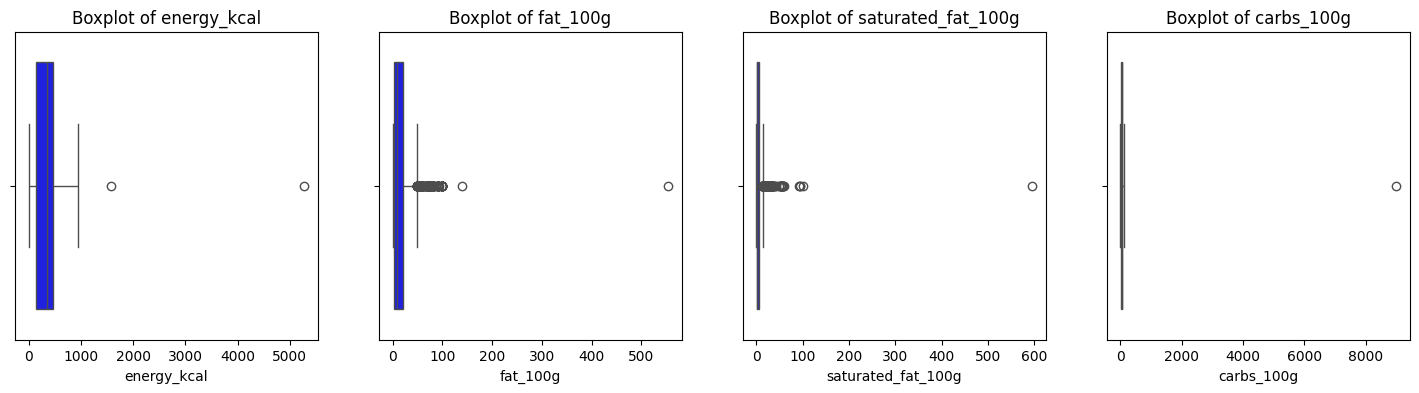

In [62]:
df_1 = df[['energy_kcal', 'fat_100g', 'saturated_fat_100g', 'carbs_100g']]

#first 5 columns
columns1 = ['energy_kcal', 'fat_100g', 'saturated_fat_100g', 'carbs_100g']

# create a grid of boxplots with 5 boxplots in one row
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 4))

for i, col in enumerate(columns1[:4]):
    sns.boxplot(data=df_1[col], orient='h', ax=axes[i], color='blue')
    axes[i].set_title(f'Boxplot of {col}')

#plot.tight_layout()
plt.show()

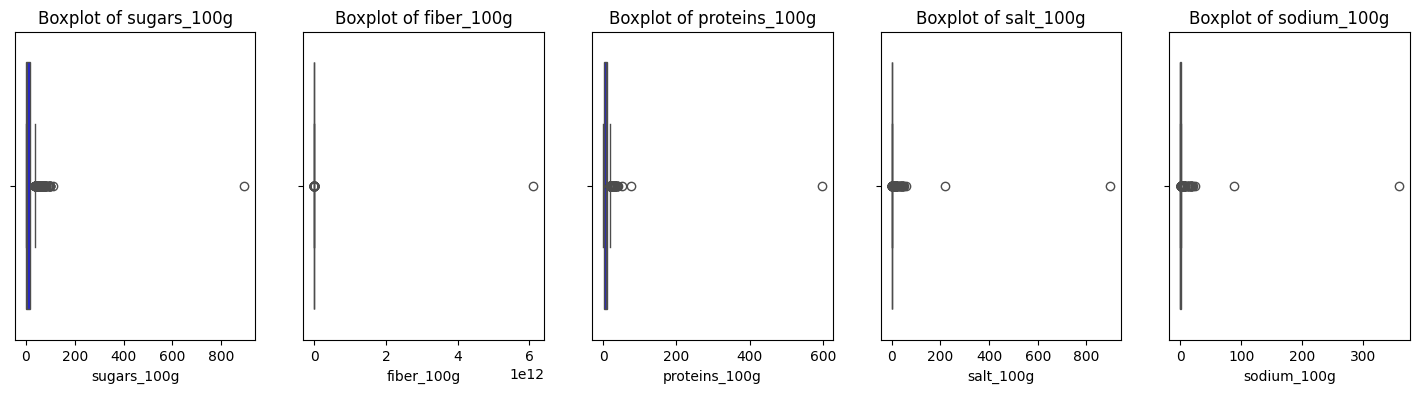

In [63]:
df_2 = df[['sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']]

#first 5 columns
columns2 = ['sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']

# create a grid of boxplots with 5 boxplots in one row
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 4))

for i, col in enumerate(columns2[:5]):
    sns.boxplot(data=df_2[col], orient='h', ax=axes[i], color='blue')
    axes[i].set_title(f'Boxplot of {col}')

#plot.tight_layout()
plt.show()

Now that we better understand how extreme these values are, let's use the IQR method to filter the data.

In [64]:
# 1. Selects only the columns with float64 data type
df_floats = df.select_dtypes(include=['float64'])

# 2. Calculates Q1, Q3, and IQR only for those columns
Q1 = df_floats.quantile(0.25)
Q3 = df_floats.quantile(0.75)
IQR = Q3 - Q1

# 3. Defines outliers specifically for the float columns
outliers_iqr = (df_floats < (Q1 - 1.5 * IQR)) | (df_floats > (Q3 + 1.5 * IQR))

# 4. Filters the original dataframe
# .any(axis=1) checks if any float column in a row is an outlier
df_clean = df[~outliers_iqr.any(axis=1)]

In [65]:
# showing that any previous outliers were removed

df_clean.describe()

,nutriscore_grade,nova_group,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish
count,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000,1863.000000
mean,1.842727,3.694042,275.111317,9.484769,2.156946,38.594810,8.584568,4.084794,6.955305,0.657203,0.262881,0.579710,0.279120,0.110574,0.189479,0.084273,0.022544
std,1.213715,0.464418,162.333282,9.185978,2.772163,26.253033,9.566722,3.294654,3.978610,0.544432,0.217772,0.493738,0.448687,0.313689,0.391994,0.277871,0.148485
min,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,111.000000,1.900000,0.333000,11.000000,1.700000,1.200000,4.165000,0.133750,0.053500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,4.000000,275.000000,5.900000,1.100000,42.700000,4.100000,3.600000,7.200000,0.610000,0.244000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,4.000000,431.000000,16.000000,2.700000,62.950000,14.000000,6.300000,9.500000,1.000000,0.400000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,4.000000,616.000000,49.500000,13.000000,90.000000,38.100000,15.300000,19.300000,2.400000,0.960000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# <h3>Task 4: Understanding Correlations</h4>

Now that our data is cleaned, we can finally understand the correlations each column has with **nutriscore_grade** whether they are positive or negative.

In [66]:
corr_matrix = df_clean.corr(numeric_only=True)
corr_matrix['nutriscore_grade'].sort_values(ascending=False)

,nutriscore_grade
nutriscore_grade,1.000000
saturated_fat_100g,0.570181
sugars_100g,0.505370
fat_100g,0.461978
energy_kcal,0.381636
contains_dairy,0.273946
carbs_100g,0.267932
sodium_100g,0.235268
salt_100g,0.235266
nova_group,0.186130


**Note**: Values closer to 1 have a more positive correlation. Values closer to -1 have a more negative correlation. Values around 0 have almost no correlation.

In [67]:
#removing columns with weaker correlations

df_clean.drop(columns=['nova_group', 'contains_eggs', 'contains_soy', 'contains_gluten', 'contains_nuts', 'contains_fish'], inplace=True)

/tmp/ipykernel_9682/2791110737.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns=['nova_group', 'contains_eggs', 'contains_soy', 'contains_gluten', 'contains_nuts', 'contains_fish'], inplace=True)


In [68]:
corr_matrix = df_clean.corr(numeric_only=True)
corr_matrix['nutriscore_grade'].sort_values(ascending=False)

,nutriscore_grade
nutriscore_grade,1.000000
saturated_fat_100g,0.570181
sugars_100g,0.505370
fat_100g,0.461978
energy_kcal,0.381636
contains_dairy,0.273946
carbs_100g,0.267932
sodium_100g,0.235268
salt_100g,0.235266
proteins_100g,-0.186524


These are the final columns we will be using for our prediction models. Finally, we can move on to training the predicion model.

# <h3>Task 4: Training the Models</h4>

We will be training and testing 4 models to make our prediciton. We will be testing a **linear regression**, **random forest generator**, **gradient boosting regressor**, and **decision tree regressor**. The model we choose for our prediction model depends on which one has the highest score. The closer the model scores to 1, the more accurate and confident the prediction will be.

In [69]:
#x is feature set
x = df_clean.drop(['nutriscore_grade'], axis=1)
#y is target value
y = df_clean['nutriscore_grade']

In [70]:
#train a LinearRegression model
from sklearn.linear_model import LinearRegression

#use cross-validation to assess the model and test its accuracy
from sklearn.model_selection import cross_val_score

model1 = LinearRegression()
cross_val_score(model1, x, y, cv=5).mean()

np.float64(0.6433780261004604)

In [71]:
from sklearn.ensemble import RandomForestRegressor

#train a RandomForestRegressor model
#use cross-validation to assess the model and test its accuracy
model2 = RandomForestRegressor(random_state=0)
cross_val_score(model2, x, y, cv=5).mean()

np.float64(0.8203163876309176)

In [72]:
from sklearn.ensemble import GradientBoostingRegressor

#train a GradientBoostingRegressor model
#use cross-validation to assess the model and test its accuracy
model3 = GradientBoostingRegressor(random_state=0)
cross_val_score(model3, x, y, cv=5).mean()

np.float64(0.7942655430117528)

In [73]:
from sklearn.tree import DecisionTreeRegressor

model4 = DecisionTreeRegressor()
cross_val_score(model4, x, y, cv=5).mean()

np.float64(0.6505704635697207)

Based on the scores, we will be using the **Random Forest Regressor** model because it achieved the highest score.

In [74]:
#training it using the entire dataset using the RandomForestRegressor
model2.fit(x, y)

RandomForestRegressor(random_state=0)

# <h3>Task 5: Testing our Predictions</h4>

Using the **Random Forest Regressor** model, we can now make predictions on the **nutriscore_grade** based on the ingredients we put in.

**Reminder**: Because we changed the nutriscore_grade data type to integers, the scores range from **0** (*the best*) to **4** (*the worst*).

In [75]:
df_clean.value_counts(subset=['nutriscore_grade'])

,count
nutriscore_grade,
2,643
3,365
0,343
1,332
4,180


We will keep this in mind as we make our predictions. Finally, let's make our predictions.

# <h3>Prediction 1:</h3>

<h4>What will the nutriscore grade be if it has...</h4>

* 25 energy kcal
* 5 grams of fat
* 3 grams of saturated fat
* 60 grams of carbs
* 20 grams of sugar
* 10 grams of fiber
* 40 grams of protein
* 0 grams of salt
* 12 grams of sodium
* Contains dairy

In [76]:
#making the prediction
model2.predict(pd.DataFrame({ 'energy_kcal': [25.0],

                              'fat_100g': [5.0],

                              'saturated_fat_100g': [3.0],

                              'carbs_100g': [60.0],

                              'sugars_100g': [20.0],

                              'fiber_100g': [10.0],

                              'proteins_100g': [40.0],

                              'salt_100g': [0.0],

                              'sodium_100g': [12.0],

                              'contains_dairy': [1] }))

array([1.84])

<h4>Result: 1.84</h4>

# <h3>Prediction 2:</h3>

<h4>What will the nutriscore grade be if it has...</h4>

* 0 energy kcal
* 30 grams of fat
* 30 grams of saturated fat
* 120 grams of carbs
* 50 grams of sugar
* 0 grams of fiber
* 5 grams of protein
* 25 grams of salt
* 30 grams of sodium
* Does not contain dairy

In [77]:
#making the prediction
model2.predict(pd.DataFrame({ 'energy_kcal': [0.0],

                              'fat_100g': [30.0],

                              'saturated_fat_100g': [30.0],

                              'carbs_100g': [120.0],

                              'sugars_100g': [50.0],

                              'fiber_100g': [0.0],

                              'proteins_100g': [5.0],

                              'salt_100g': [25.0],

                              'sodium_100g': [30.0],

                              'contains_dairy': [0] }))

array([3.66])

<h4>Result: 3.66</h4>

# <h3>Prediction 3:</h3>

<h4>What will the nutriscore grade be if it has...</h4>

* 80 energy kcal
* 0 grams of fat
* 0 grams of saturated fat
* 500 grams of carbs
* 0 grams of sugar
* 20 grams of fiber
* 50 grams of protein
* 0 grams of salt
* 0 grams of sodium
* Contains dairy

In [78]:
#making the prediction
model2.predict(pd.DataFrame({ 'energy_kcal': [80.0],

                              'fat_100g': [0.0],

                              'saturated_fat_100g': [0.0],

                              'carbs_100g': [500.0],

                              'sugars_100g': [0.0],

                              'fiber_100g': [20.0],

                              'proteins_100g': [50.0],

                              'salt_100g': [0.0],

                              'sodium_100g': [0.0],

                              'contains_dairy': [1] }))

array([0.37])

<h4>Result: 0.37</h4>